In [198]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [199]:
caminho_arquivo = "tratados_3det/iron/iron1E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [0, 0, 0, 0, 11, 1, 3, 0, 0, 6, 2, 9, 39, 0, 10, 0, 2, 1, 0, 0, 1, 0, 1, 0, 7, 0, 8, 0, 0, 2, 1, 0, 1, 2, 1, 0, 0, 3, 0, 2, 0, 3, 1, 6, 0, 1, 4, 9, 0, 0, 5, 0, 0, 0, 0, 1, 0, 2, 1, 2, 0, 10, 1, 0, 0, 0, 0, 4, 0, 2, 2, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 5, 0, 1, 1, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 2, 0, 7, 4, 2, 0, 0, 0, 0, 0, 0, 1, 0, 5, 1, 1, 3, 1, 0, 0, 3, 1, 0, 0, 17, 9, 0, 3, 1, 1, 0, 0, 12, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 6, 0, 0, 0, 2, 0, 0, 0, 4, 0, 0, 10, 0, 4, 0, 1, 1, 0, 0, 8, 3, 0, 0, 2, 0, 1, 0, 0, 5, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 3, 0, 3, 2, 0, 3, 1, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 15, 2, 15, 0, 0, 0, 0, 8, 18, 6, 0, 1, 0, 4, 4, 0, 5, 1, 0, 0, 0, 1, 5, 9, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 15, 0, 0, 0, 0, 0, 0, 0, 1, 0, 15, 0, 0, 0, 11, 0, 1, 0, 1, 2, 1, 2, 0, 0, 0, 0, 0, 11, 0, 7, 6, 5, 0, 2, 1, 1, 2, 0, 17, 0, 6, 0, 0, 0, 2, 3, 0, 0, 0, 0, 13, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 3, 6, 4, 4,

In [200]:
# Posição dos tanques
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1 = dados_processados['total_por_detector']['TRIG1']
trig2 = dados_processados['total_por_detector']['TRIG2']
trig3 = dados_processados['total_por_detector']['TRIG3']

print(trig1,'\n',
      trig2,'\n',
      trig3)

[0, 1, 0, 0, 28, 5, 10, 0, 0, 14, 5, 18, 73, 0, 28, 0, 3, 6, 1, 0, 10, 0, 3, 0, 21, 0, 28, 0, 1, 4, 1, 1, 1, 10, 4, 0, 0, 3, 0, 10, 0, 13, 4, 9, 1, 3, 12, 20, 0, 1, 9, 1, 0, 0, 0, 6, 1, 5, 4, 4, 0, 26, 2, 0, 0, 0, 0, 14, 0, 3, 4, 1, 3, 2, 0, 3, 0, 1, 0, 0, 1, 10, 1, 2, 7, 0, 0, 2, 12, 0, 0, 3, 1, 2, 0, 3, 2, 12, 9, 6, 0, 0, 0, 0, 0, 0, 2, 0, 9, 6, 1, 5, 4, 1, 2, 5, 4, 0, 1, 44, 20, 0, 9, 1, 2, 1, 0, 17, 1, 0, 2, 0, 1, 10, 1, 0, 0, 0, 0, 18, 0, 2, 0, 8, 0, 0, 0, 7, 1, 2, 16, 0, 7, 0, 2, 2, 1, 0, 14, 4, 0, 0, 4, 1, 2, 0, 0, 13, 0, 1, 0, 7, 0, 1, 2, 0, 0, 6, 3, 17, 0, 8, 3, 0, 4, 1, 2, 1, 0, 0, 0, 5, 9, 0, 0, 0, 0, 0, 0, 3, 0, 40, 8, 28, 0, 1, 0, 0, 18, 41, 11, 0, 3, 1, 8, 15, 0, 7, 3, 0, 0, 0, 3, 17, 19, 5, 1, 1, 7, 4, 0, 6, 0, 0, 9, 1, 1, 2, 0, 0, 0, 1, 0, 0, 0, 24, 0, 0, 36, 0, 0, 0, 0, 0, 0, 0, 1, 0, 34, 0, 1, 0, 28, 1, 2, 0, 4, 11, 2, 8, 0, 1, 0, 1, 0, 27, 0, 17, 9, 16, 1, 4, 1, 1, 3, 0, 38, 0, 10, 0, 0, 0, 3, 13, 0, 0, 1, 0, 32, 0, 1, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 22, 5, 9, 7, 12

In [201]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [202]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-3.501654,-70.907729,4.919,3.989,3.721,167.237412,0.000371,0.000301,0.00028,436.285617,503.888939,508.735608


In [ ]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)


data2 = {
    'rho':rho,
    'r_b':r_b
}

df3 = pl.DataFrame(data2)

#df3.write_csv('bary_dat/' + caminho_arquivo.split('/')[-1] + '_bary.csv', separator= '\t', include_header= False)

[0.0003705955810977672, 0.00030052973632831734, 0.0002803387186958308] [436.28561685361797, 503.8889391428337, 508.7356076318323]


In [204]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Iron 1E15'

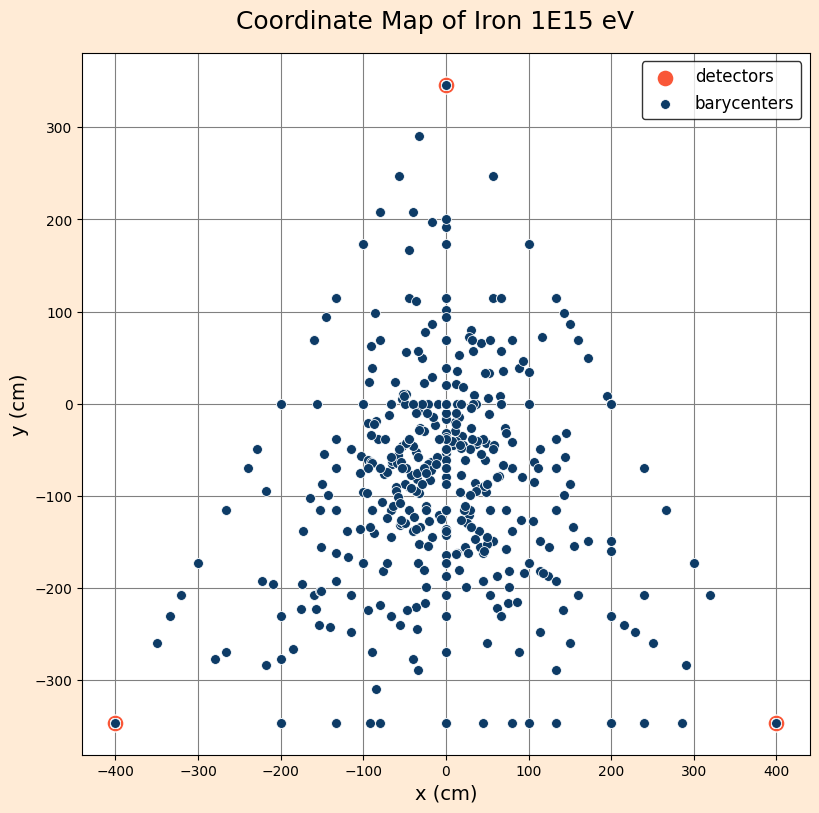

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

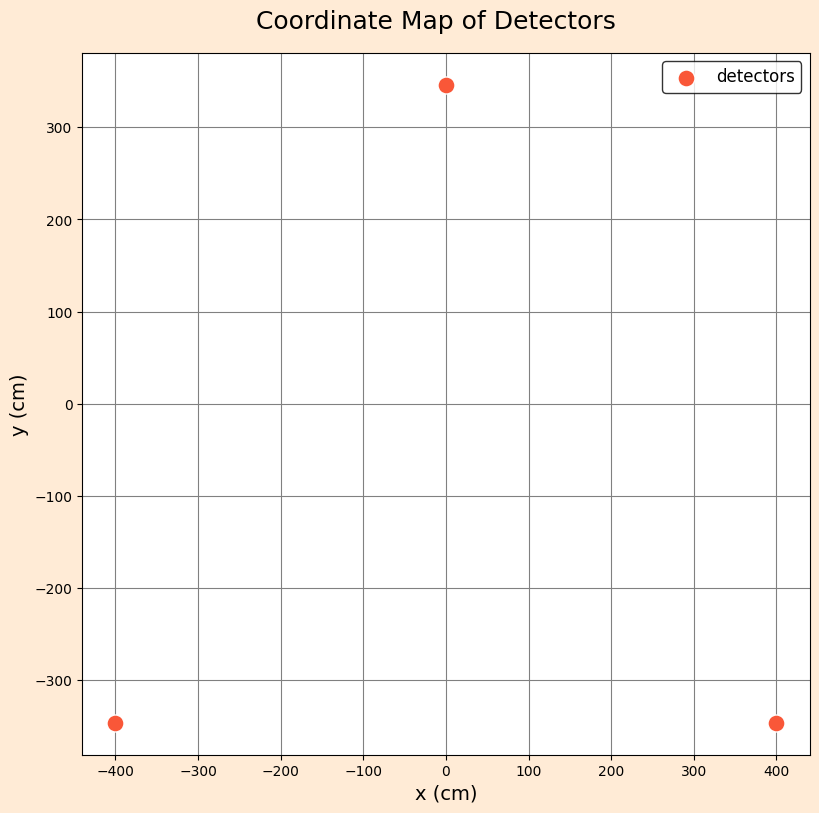

In [206]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

[1.03619068e-15 1.38609350e-02]
[4.41496002 5.09542909 5.77675041]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3850950568.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3850950568.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.418964,14.0,14.00294,0.021001
5.087426,14.499687,14.493811,0.040529
5.780749,15.0,15.002936,0.019576


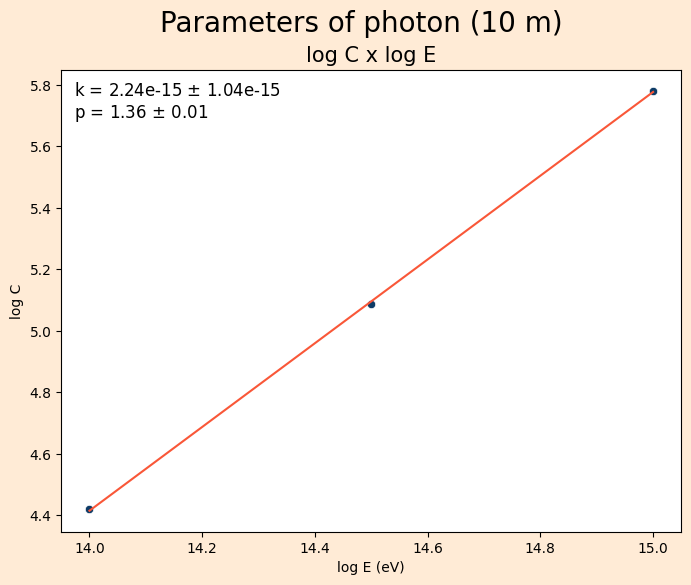

In [209]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [2.624E4, 1.223E5, 6.036E5]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[1.35649802e-13 3.84310014e-03]
[4.62103782 5.21341874 5.8065416 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\791415411.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\791415411.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.619928,14.0,13.999064,0.006689
5.215638,14.499687,14.501559,0.012908
5.805433,15.0,14.999065,0.006235


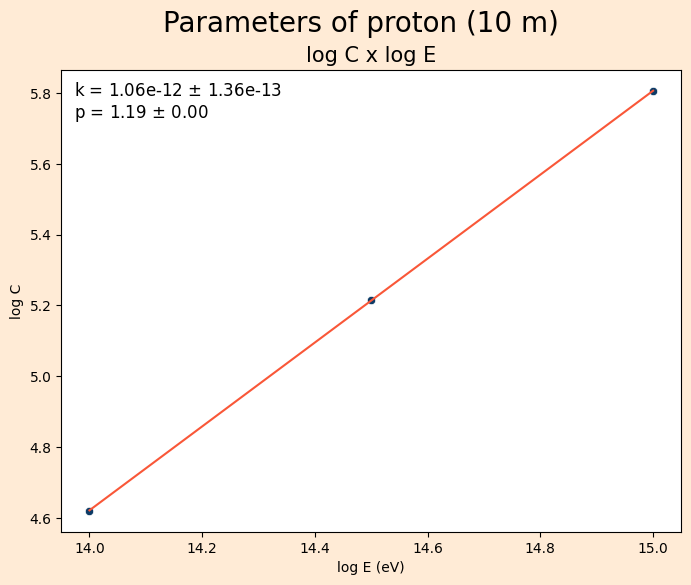

In [ ]:
# Fit do próton
from scipy.optimize import curve_fit

C = [4.168e+04, 1.643e+05, 6.389e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.12202004e-06 2.38934361e-01]
[4.27281222 4.66000189 5.04767649]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3149765414.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3149765414.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.34183,14.0,14.089071,0.636221
4.522053,14.499687,14.321657,1.22782
5.116608,15.0,15.088959,0.593061


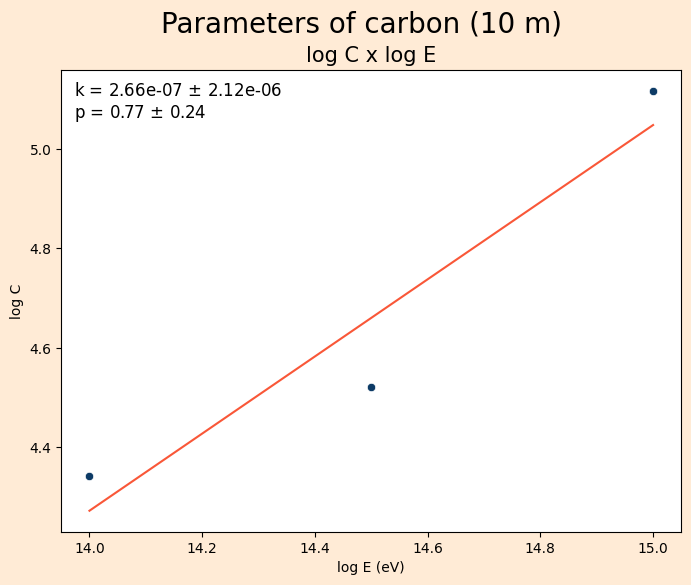

In [212]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [2.197e+04, 3.327e+04, 1.308e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[6.16995911e-16 8.87504152e-02]
[3.71289752 4.40512596 5.09822138]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\1451245844.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\1451245844.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.687261,14.0,13.981494,0.132182
4.456366,14.499687,14.536675,0.255094
5.072617,15.0,14.981518,0.123215


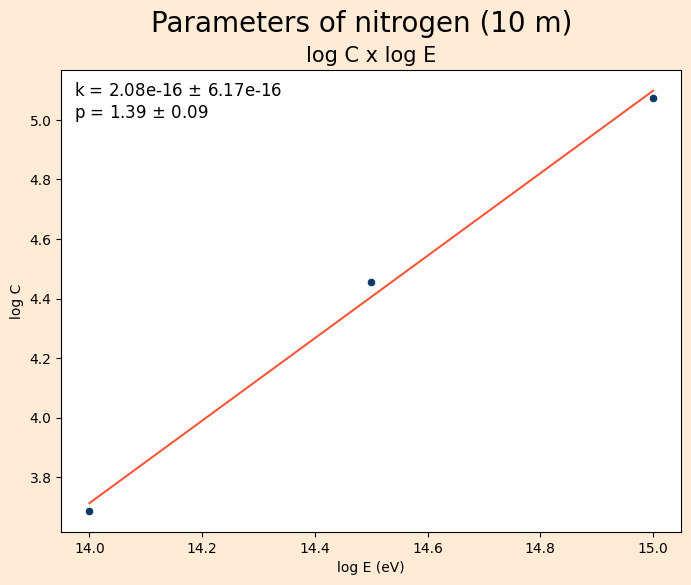

In [214]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [4867, 2.86e+04, 1.182e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\1425185388.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\1425185388.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


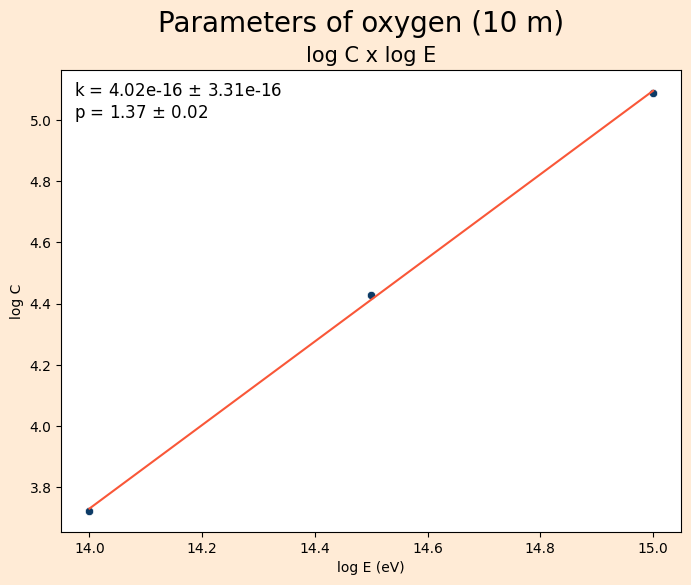

In [215]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3778982861.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22420\3778982861.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


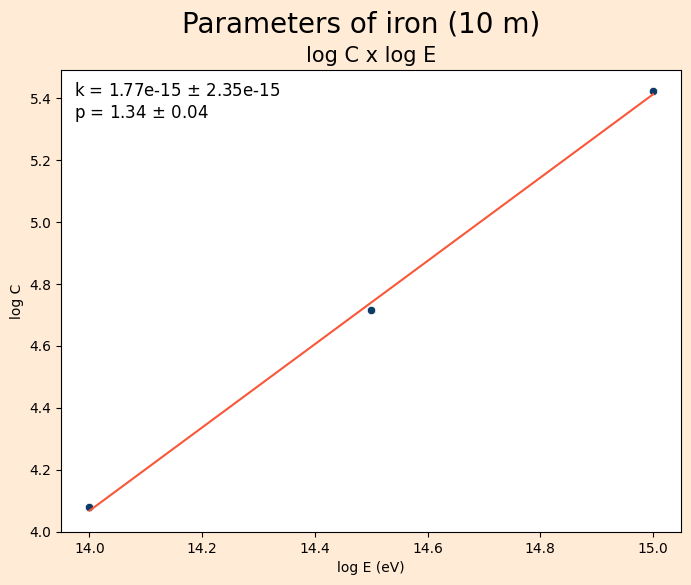

In [216]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [217]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,5.3050e12,2.6581e12,2.1065e11,7.0306e12,6.6489e12,1.3719e12
3.1600e14,1.7443e13,1.0043e13,1.8771e12,2.9232e13,2.4254e13,6.4712e12
1.0000e15,5.9873e13,3.6083e13,2.3525e13,9.5288e13,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

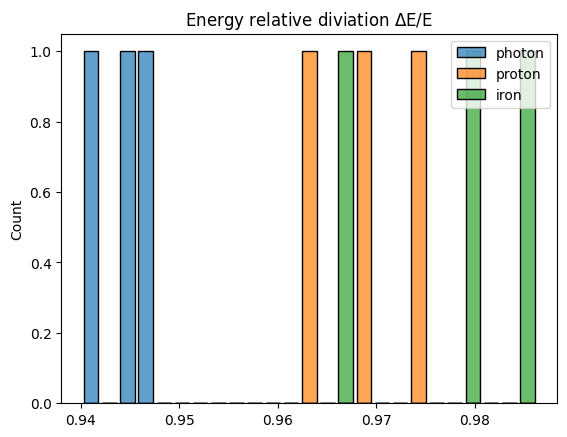

In [218]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_iron.append(aux3)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')